<h1 align=center>Global Consumer Intelligence Course (GCIC) Final Assignment</h4>

<h5 align=center>Authored by Nathaniel Jonathan Rusli (ITB)</h5>

## About the Data

As mentioned in the dataset overview, the dataset used is a modified version of [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset) with over 44 features and 1470 entires. Further information about the data used in this project are available on the EDA part.

## Imports and Configs

#### General Libraries Imports

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import hvplot.pandas
import warnings

#### Machine Learning Model Libraries Imports

In [10]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    f1_score, recall_score, roc_auc_score, roc_curve
)

#### Scientific Computing Library Import

In [12]:
from scipy.stats import mannwhitneyu, ttest_ind

#### Additional Library Configs

In [13]:
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:.2f}".format)
np.random.seed(42)
%matplotlib inline
sns.set_style('whitegrid')
sns.set_palette('pastel')
warnings.filterwarnings('ignore')

**Python Kernel Used**: Python 3 (ipykernel)

## Exploratory Data Analysis (EDA)

#### Data Loading and Overview

The following EDA in this section is an overview to the data that we'll be using, presenting 1,470 entries with 44 feature columns. Majority of the feaures are numerical features and there are some categorical features.

In [17]:
df = pd.read_csv('data.csv')

In [18]:
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,PerformanceIndex,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyAchievement,NumCompaniesWorked,Over18,OverTime,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,HowToEmploy,Incentive,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,19479,8,Y,16,1,1,40,0,8,0,1,6,4,0,5,agent_B,0,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,24907,1,Y,7,4,4,40,1,10,3,3,10,7,1,7,intern,3431,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2396,6,Y,32,3,2,40,0,7,3,3,0,0,0,0,intern,0,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,23159,1,Y,28,1,3,40,0,8,3,3,8,7,3,0,intern,0,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,16632,9,Y,10,2,4,40,1,6,3,3,2,2,2,2,agent_C,0,2,3029,3,2,0,0,0,0,3,2023


In [19]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'PerformanceIndex',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyAchievement', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'HowToEmploy', 'Incentive', 'RemoteWork', 'MonthlyIncome',
       'StressRating', 'WelfareBenefits', 'InHouseFacility',
       'ExternalFacility', 'ExtendedLeave', 'FlexibleWork',
       'StressSelfReported', 'Year'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  PerformanceIndex          1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

#### Descriptive Statistics 

In [22]:
df.describe()

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,PerformanceIndex,JobInvolvement,JobLevel,JobSatisfaction,MonthlyAchievement,NumCompaniesWorked,OverTime,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Incentive,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.90,9.24,2.91,1.00,1022.19,2.72,65.89,2.73,2.07,2.73,14313.10,2.68,15.33,2.53,2.71,40.00,0.79,11.25,2.80,2.76,7.01,4.23,2.20,4.12,1142.87,2.82,6922.26,2.50,2.50,0.60,0.29,0.25,0.55,2.10,2023.20
std,9.15,8.13,1.03,0.00,602.77,1.09,20.33,0.71,1.11,1.10,7117.79,2.50,12.52,0.99,1.08,0.00,0.85,7.75,1.29,0.71,6.11,3.59,3.21,3.57,1506.26,1.23,1977.10,0.88,1.13,0.49,0.46,0.43,0.50,0.95,0.40
min,18.00,1.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,2094.00,0.00,0.00,1.00,1.00,40.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1329.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,2023.00
25%,30.00,2.00,2.00,1.00,486.25,2.00,48.00,2.00,1.00,2.00,8047.00,1.00,5.00,2.00,2.00,40.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00,0.00,2.00,5542.25,2.00,1.00,0.00,0.00,0.00,0.00,1.00,2023.00
50%,36.00,7.00,3.00,1.00,1018.50,3.00,66.00,3.00,2.00,3.00,14235.50,2.00,13.00,3.00,3.00,40.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00,0.00,3.00,6814.50,2.00,2.00,1.00,0.00,0.00,1.00,2.00,2023.00
75%,43.00,14.00,4.00,1.00,1554.75,4.00,83.75,3.00,3.00,4.00,20461.50,4.00,24.00,3.00,4.00,40.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00,2394.25,4.00,8264.75,3.00,4.00,1.00,1.00,1.00,1.00,3.00,2023.00
max,60.00,29.00,5.00,1.00,2068.00,4.00,100.00,4.00,5.00,4.00,26999.00,9.00,61.00,4.00,4.00,40.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00,6047.00,5.00,12612.00,5.00,4.00,1.00,1.00,1.00,1.00,5.00,2024.00


#### Detecting Missing Values and Duplicates

Overall, this dataset is clean as it contains no missing values or duplicate values as shown below.

In [24]:
print("Missing values of each dataset's features")
df.isna().sum()

Missing values of each dataset's features


Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
PerformanceIndex            0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyAchievement          0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
HowToEmploy                 0
Incentive 

In [25]:
print(f"Number of duplicated rows: {df.duplicated().sum()}")

Number of duplicated rows: 0


#### Cardinality Check

Some features have high cardinality as expected, such as monthly achievement and monthly income which varies across different employees. But some features like EmployeeCount, Over18, StandardHours contain only 1 unique value which presents no variability and utterly useless for our future machine learning model. There's also feature like EmployeeNumber which directly IDs the employees and may not contain useful information.

In [27]:
print("Number of unique values for each feature")
df.nunique()

Number of unique values for each feature


Age                           43
Attrition                      2
BusinessTravel                 3
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1442
EnvironmentSatisfaction        4
Gender                         2
PerformanceIndex              71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyAchievement          1427
NumCompaniesWorked            10
Over18                         1
OverTime                      55
PerformanceRating              4
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBalance                4
YearsAtCompany                37
YearsInCurrentRole            19
YearsSince

### Feature Understanding (Univariate and Multivariate Analysis)

#### Target: Attrition

It is crucical to identify the distribution of potential target features, such as Attrition in this case which is imbalanced, with 'No' as the majority value.

In [30]:
df_attrition = df['Attrition'].value_counts().reset_index()
df_attrition.columns = ['Status', 'Count']

df_attrition.hvplot.barh(
    x='Status',
    y='Count', 
    subplots=False, 
    title='Attrition Distribution',
    grid=True
)

:Bars   [Status]   (Count)

#### Demographics

Although may not be directly actionable, demographics data distribution may help the process of the our proof-of-concept model development.

##### Age

In [33]:
df.hvplot.hist(
    y='Age', 
    subplots=False, 
    bins=10,
    title='Employees Age Distribution',
    grid=True
)

:Histogram   [Age]   (Count)

##### Gender

In [35]:
df['Gender'].value_counts().hvplot.bar(
    subplots=False, 
    title='Employees Gender Distribution',
    grid=True
)

:Bars   [Gender]   (count)

##### Marital Status

In [37]:
df['MaritalStatus'].value_counts().hvplot.bar(
    subplots=False, 
    title='Employees Marital Status Distribution',
    grid=True
)

:Bars   [MaritalStatus]   (count)

##### Education Field

In [39]:
df['EducationField'].value_counts().hvplot.bar(
    subplots=False, 
    title='Employees Education Field Distribution',
    grid=True
)

:Bars   [EducationField]   (count)

#### Work Related Features

##### Department

In [42]:
df['Department'].value_counts().hvplot.bar(
    subplots=False, 
    title='Department Distribution',
    grid=True,
    color='green'
)

:Bars   [Department]   (count)

##### Job Role

In [44]:
df['JobRole'].value_counts().hvplot.bar(
    subplots=False, 
    title='JobRole Distribution',
    grid=True,
    color='green',
    rot=90
)

:Bars   [JobRole]   (count)

#### Other Interesting Features

The following features are actionable, and identifying the distribution may be useful for root causes identification.

##### Monthly Income

In [47]:
df.hvplot.kde(
    y='MonthlyIncome',
    subplots=False, 
    title='Monthly Income Distribution',
    filled=True,
    grid=True,
    color='yellow'
)

:Distribution   [MonthlyIncome]   (Density)

##### Stress Rating

In [49]:
df['StressRating'].value_counts().sort_index().hvplot.bar(
    subplots=False, 
    title='Stress Rating Distribution',
    grid=True,
    color='yellow'
)

:Bars   [StressRating]   (count)

##### Remote Work

Feature interpretation:

. 'on-site work' and 
5. 'full remote'

In [52]:
df['RemoteWork'].value_counts().sort_index().hvplot.bar(
    subplots=False, 
    title='Remote Work Distribution',
    grid=True,
    color='yellow'
)

:Bars   [RemoteWork]   (count)

#### Bivariate Analysis: Specific Factors' Relationship to Attrition

The following explorations are directly correlated to their relationship towards Attrition. Certain trends of features may be spotted early before confirmation with our ML model.

##### Attrition by Department

In [55]:
df_dept_attr = df.groupby(['Department', 'Attrition'])

In [56]:
print(df_dept_attr.size())

Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           825
                        Yes          136
Sales                   No           356
                        Yes           90
dtype: int64


In [57]:
df_dept_attr.size().unstack().hvplot.bar(
    stacked=True,
    title='Attrition on Every Department',
    ylabel='Employee Count',
    legend='top_right'
)

:Bars   [Department,Attrition]   (value)

##### Attrition by Stress Level

In [59]:
df.groupby(['StressRating', 'Attrition']).size().unstack().hvplot.bar(
    stacked=True,
    title='Attrition on Every Stress Level',
    ylabel='Employee Count',
    legend='top_right'
)

:Bars   [StressRating,Attrition]   (value)

##### Attrition by Income

In [61]:
df.groupby(['JobRole', 'Attrition']).size().unstack().hvplot.barh(
    stacked=True,
    title='Attrition per Job Role',
    height=500
)

:Bars   [JobRole,Attrition]   (value)

##### Attrition by Age

In [63]:
df.hvplot.kde(
    y='Age',
    by='Attrition',
    title='Age Distribution: Stay vs Leave',
    alpha=0.5,
    legend='top_right'
)

:NdOverlay   [Attrition]
   :Distribution   [Age]   (Density)

##### Attrition by Over Time

In [65]:
df.hvplot.hist(
    y='OverTime',
    by='Attrition',
    subplots=False, 
    bins=10,
    title='Overtime Distribution by Over Time',
    grid=True
)

:NdOverlay   [Attrition]
   :Histogram   [OverTime]   (Count)

##### Attrition by Income

In [67]:
df.hvplot.box(
    y='MonthlyIncome',
    by='Attrition',
    title='Income Comparison: Stay vs Leave',
    legend=False
)

:BoxWhisker   [Attrition]   (MonthlyIncome)

##### Attrition by Incentive

In [69]:
df.hvplot.box(
    y='Incentive',
    by='Attrition',
    title='Incentive Comparison: Stay vs Leave',
    legend=False
)

:BoxWhisker   [Attrition]   (Incentive)

##### Attrition by Years at Company

In [71]:
df.hvplot.hist(
    y='YearsAtCompany',
    by='Attrition',
    subplots=False,
    alpha=0.5,      
    bins=15,
    title='Employees Years at Company: Stay vs Leave'
)

:NdOverlay   [Attrition]
   :Histogram   [YearsAtCompany]   (Count)

#### More Interesting Explorations

##### Stress Gap Analysis

In [74]:
df.hvplot.scatter(
    x='StressRating',
    y='StressSelfReported',
    by='Attrition',
    alpha=0.6,
    s=50,         
    jitter=0.3,
    title='Stress Gap Analysis: Rating vs Self-Reported'
)

:NdOverlay   [Attrition]
   :Scatter   [StressRating]   (StressSelfReported)

##### Channel Effectiveness

In [76]:
df.groupby(['HowToEmploy', 'Attrition']).size().unstack().hvplot.barh(
    stacked=True,
    title='Recruitment Channel Effectivity Analysis',
    height=400
)

:Bars   [HowToEmploy,Attrition]   (value)

##### Job Satisfaction and Income Distribution

In [78]:
df.hvplot.scatter(
    x='JobSatisfaction',
    y='MonthlyIncome',
    by='Attrition',  
    alpha=0.7,
    s=60,
    jitter=0.4,     
    title='Income and Job Satisfaction Distribution by Attrition',
    legend='top_left'
)

:NdOverlay   [Attrition]
   :Scatter   [JobSatisfaction]   (MonthlyIncome)

### Heatmap

The following heatmap may give us hints on several relationship of the features. But focusing on our potential target i.e. Attrition, it hasn't exhibit any obvious strong correlation with any of the other numerical features.

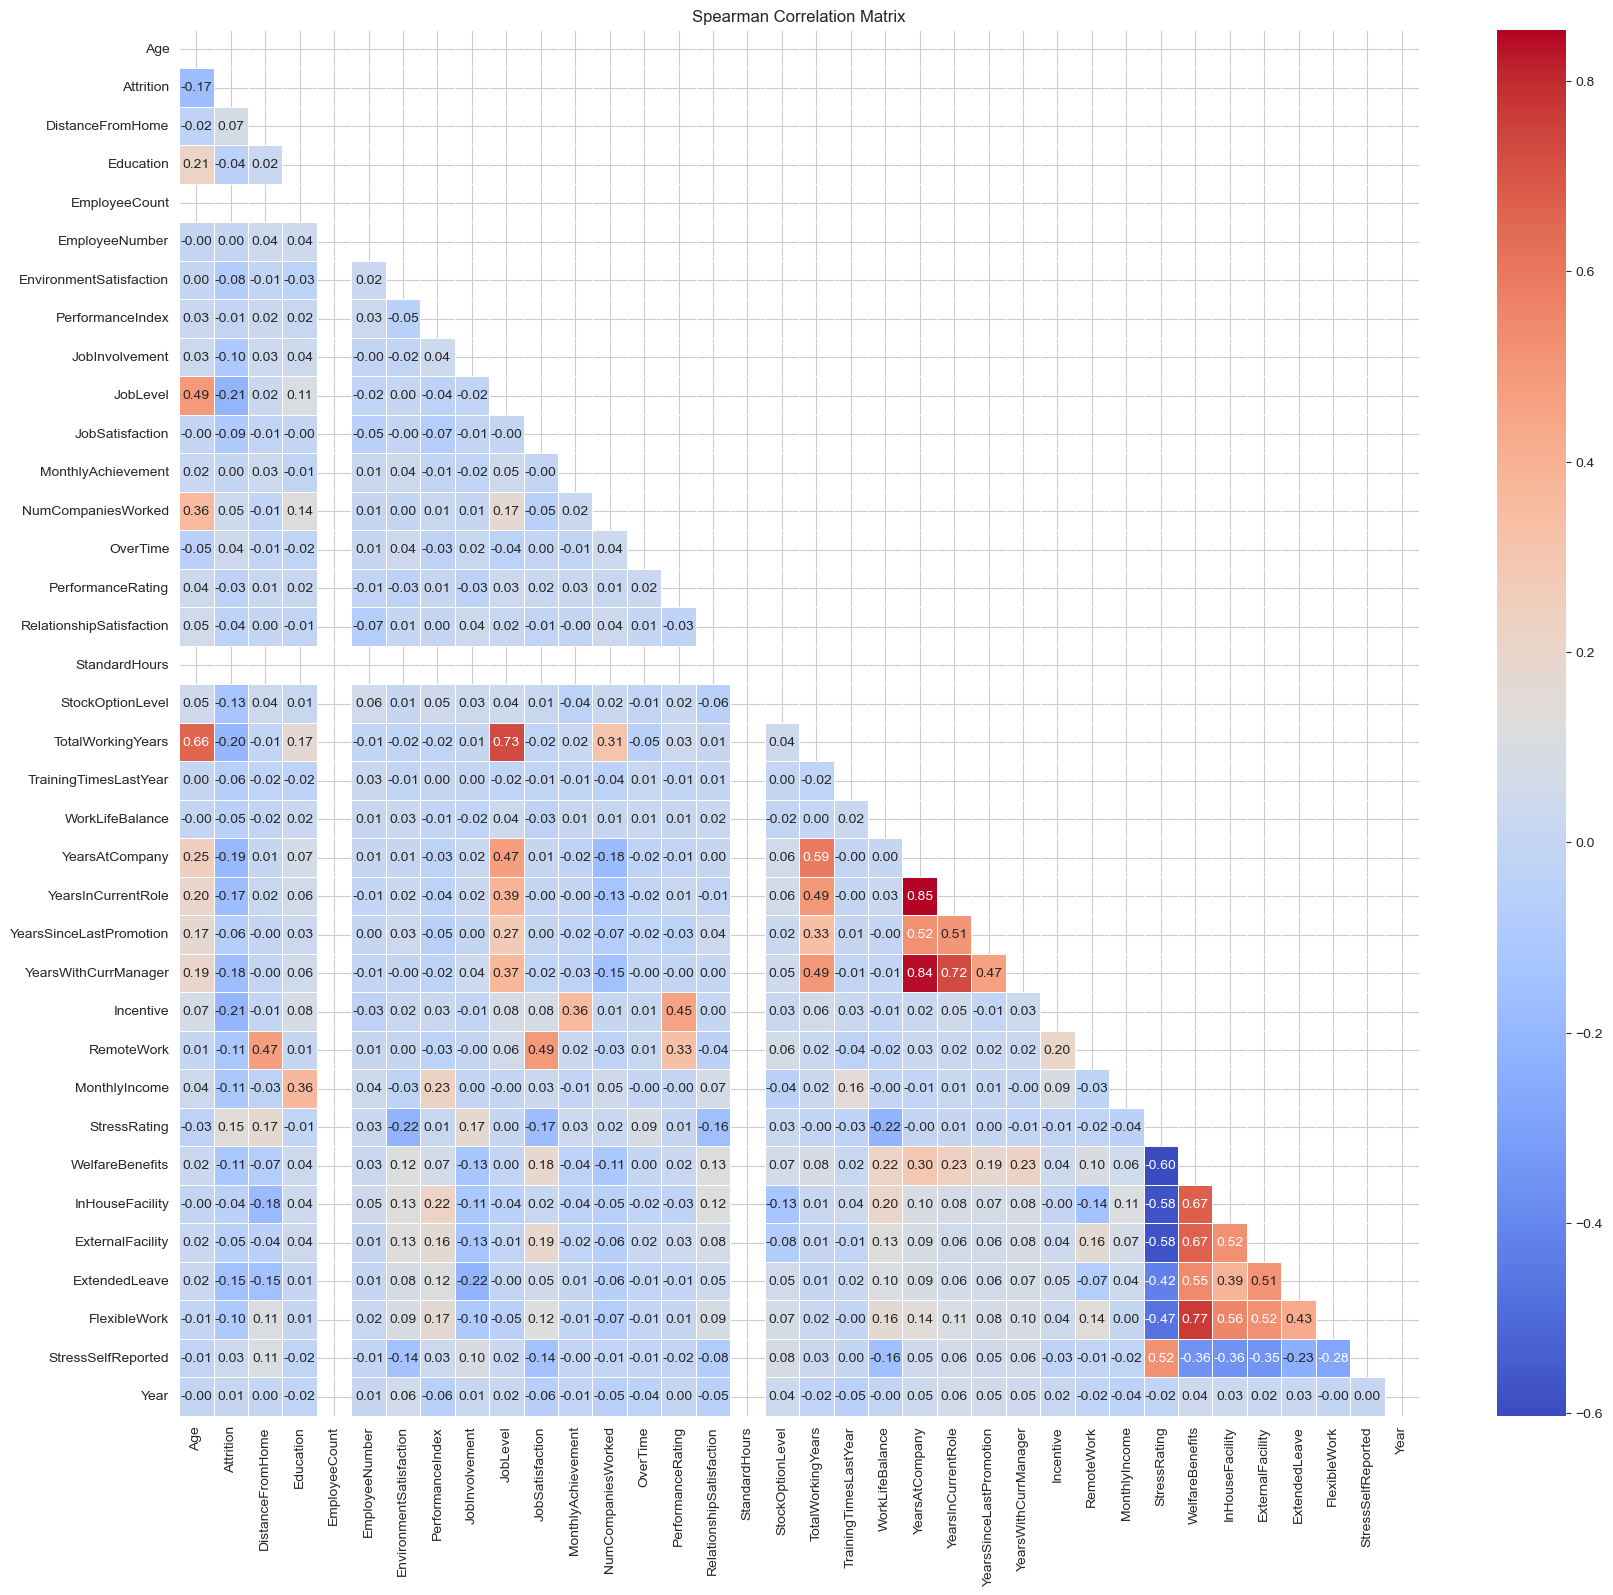

In [80]:
df_heatmap = df.copy()
df_heatmap['Attrition'] = df_heatmap['Attrition'].map({'Yes': 1, 'No': 0})
corr_matrix = df_heatmap.corr(method='spearman', numeric_only=True)
plt.figure(figsize=(20, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f",      
            cmap='coolwarm', 
            mask=mask,      
            linewidths=0.5)
plt.title('Spearman Correlation Matrix')
plt.show()

## Problem Definition: Employee Attrition as a Financial & Operational Risk

####  The Context
Employee churn (attrition) is often viewed as a routine HR metric, but in reality, it is a silent profit killer. For this organization, internal data indicates that **High Stress (Burnout)** and **Low Incentives** are the primary drivers of turnover. This project aims to move beyond *post-mortem* analysis (exit interviews) and move toward *predictive* intervention using Machine Learning.

#### The Financial Impact
The cost of ignoring these drivers is mathematically severe. According to **SHRM**, replacing a salaried employee costs the organization between **6 to 9 months of that employee's salary** in recruiting and training costs alone. Furthermore, **Gallup** estimates that replacing a technical professional costs **80% of their annual salary**, while replacing a leader can cost up to **200%**. 

When high performers leave due to a lack of incentives, the loss is compounded. **Forbes** notes that top performers can be **400% more productive** than average employees. Losing these individuals due to manageable factors like compensation structure is an avoidable capital loss.

#### The Human Factor: Burnout
The data suggests "High Stress" is a key feature in our churn instances. This aligns with broader market trends; **Gallup** research indicates that employees experiencing burnout are **2.6x more likely** to actively seek a new job. 

#### Project Objective
The goal of this analysis is to build a classification model that identifies employees at risk of leaving *before* they resign. By correlating features such present in the dataset with attrition status, we aim to provide actionable insights for retention strategies.

#### References

**The Cost of Replacement**
* [Gallup - 42% of Employee Turnover Is Preventable](https://www.gallup.com/workplace/646538/employee-turnover-preventable-often-ignored.aspx)
* [SHRM (via PeopleKeep) - The Real Cost of Employee Turnover](https://www.peoplekeep.com/blog/employee-retention-the-real-cost-of-losing-an-employee)

**Burnout & Stress Impact**
* [Gallup - Employee Burnout: The Biggesthttps://www.gallup.com/workplace/288539/employee-burnout-biggest-myth.aspxth.aspx)
* [Mental Health UK - The Burnout Report 2024](https://mentalhealth-uk.org/burnout/)

**Compensation & High Performers**
* [Forbes - Keeping Top Performers Requires Extra Effort](https://www.forbes.com/councils/forbescoachescouncil/2020/03/20/keeping-top-performers-requires-extra-effort-in-todays-market/)
* [McKinsey - The Powerful Role Financial Incentives Can Play](https://www.mckinsey.com/capabilities/transformation/our-insights/the-powerful-role-financial-incentives-can-play-in-a-transformation)
* [Harvard Business Review - Compensation Packages That Actually Drive Performance](https://hbr.org/2021/01/compensation-packages-that-actually-drive-performance)

## Feature Engineering

The following feature engineering process is based off the previous data exploration (EDA) and through domain knowledge. Some features are dropped as it contains no useful information and some are added as result of domain knowledge.

In [83]:
def preprocess_data(df):
    data = df.copy()

    # Drop features with only 1 unique values (as it provides no useful information)
    informationless_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
    data = data.drop(columns=[c for c in informationless_cols if c in data.columns], errors='ignore')

    # Domain knowledge feature engineering
    total_working_years = data['TotalWorkingYears'].replace(0, 1)
    data['LoyaltyRatio'] = data['YearsAtCompany'] / total_working_years
    satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance']
    valid_sat_cols = [c for c in satisfaction_cols if c in data.columns]
    if valid_sat_cols:
        data['TotalSatisfactionScore'] = data[valid_sat_cols].sum(axis=1)

    # Drop other features
    manual_drop_cols = ['ExternalFacility']
    data = data.drop(columns=[c for c in manual_drop_cols if c in data.columns], errors='ignore')

    return data

In [84]:
df_model = preprocess_data(df)

## Modelling and Validation

As a proof-of-concept, CatBoostClassifier is used as it offers solid performance with its inherent and mature target encoding, and other capabilities of robust handling towards missing values, categorical values, perfect as a base model for our POC.

In [86]:
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition'].map({'Yes': 1, 'No': 0})

In [87]:
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = CatBoostClassifier(
    iterations=500,            
    learning_rate=0.1,         
    depth=6,                   
    cat_features=categorical_features, 
    auto_class_weights='Balanced',     
    eval_metric='F1',          
    verbose=0,                  
    random_seed=42,
    allow_writing_files=False
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50   
)

# Generate Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability of Class 1 (Attrition)

The metrics used for this case are Recall as the main metrics as we prioritize spotting as many employees who are about to churn as we can (we want to maximize True Positives and minimize False Negatives). ROC-AUC Score is also used and serves as an overall validation of the model.

   Recall (Churn) : 0.7500 (Ability to detect leaving employees)
   ROC-AUC Score  : 0.7900 (Overall model discriminative power)

   Detailed Classification Report:

              precision    recall  f1-score   support

    Stay (0)       0.93      0.70      0.80       246
   Leave (1)       0.33      0.75      0.46        48

    accuracy                           0.71       294
   macro avg       0.63      0.72      0.63       294
weighted avg       0.84      0.71      0.74       294



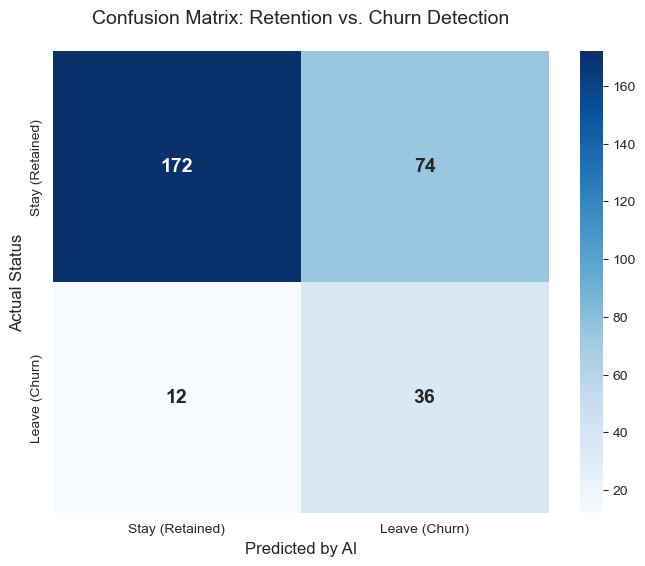

In [88]:
# Calculate Core Metrics
recall_churn = recall_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"   Recall (Churn) : {recall_churn:.4f} (Ability to detect leaving employees)")
print(f"   ROC-AUC Score  : {roc_auc:.4f} (Overall model discriminative power)")
print("\n   Detailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Leave (1)']))

cm = confusion_matrix(y_test, y_pred)
labels = ['Stay (Retained)', 'Leave (Churn)']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, 
            annot_kws={"size": 14, "weight": "bold"})
plt.xlabel('Predicted by AI', fontsize=12)
plt.ylabel('Actual Status', fontsize=12)
plt.title('Confusion Matrix: Retention vs. Churn Detection', fontsize=14, pad=20)
plt.show()

To spot critical causes correlated (not causal) to Attrition, feature importance are utilized to serve this purpose. As we can see, two of the top actionable features in taking action to prevent Attrition are Incentive and Stress Rating. Both factors have to be assessed further using other methods like statistical modelling, external sources validation and referring back to EDA to ensure they're not coincidences.

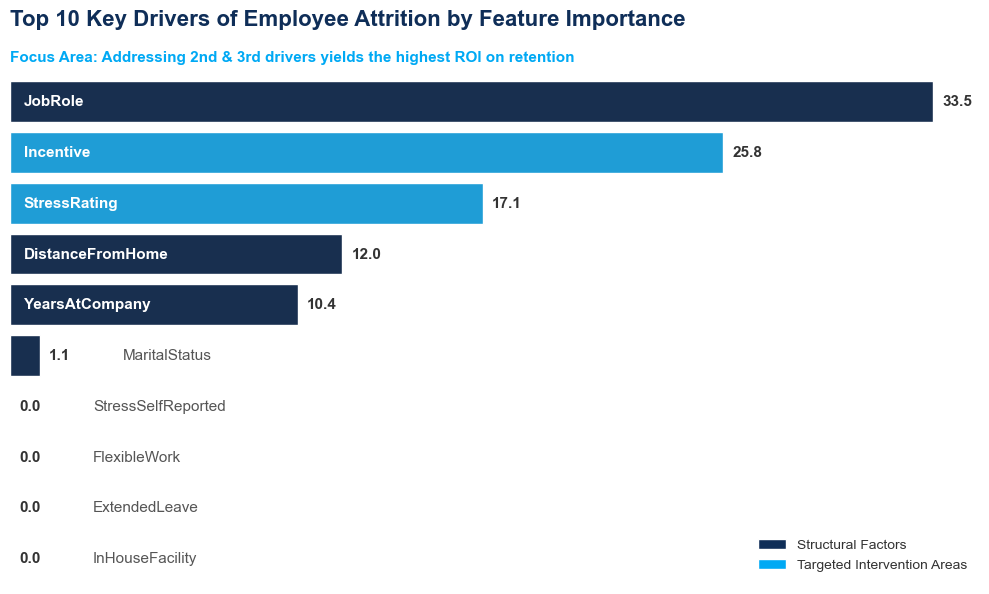

In [148]:
feature_importance = model.get_feature_importance()
fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)

primary_col = '#0F2E58'  
highlight_col = '#00A9F4'
bar_colors = [highlight_col if i in [1, 2] else primary_col for i in range(len(fi_df))]
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=fi_df, 
    palette=bar_colors, 
    hue='Feature', 
    legend=False,
    ax=ax
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([]) 
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])

max_val = fi_df['Importance'].max()

for i, (idx, row) in enumerate(fi_df.iterrows()):
    val = row['Importance']
    name = row['Feature']

    if i < 5:
        ax.text(val + (max_val * 0.01), i, f'{val:.1f}', 
                va='center', ha='left', color='#333333', fontsize=11, fontweight='bold')
        ax.text(0.5, i, name, 
                va='center', ha='left', color='white', fontsize=11, fontweight='bold')
    else:
        ax.text(val + (max_val * 0.01), i, f'{val:.1f}', 
                va='center', ha='left', color='#333333', fontsize=11, fontweight='bold')
        ax.text(val + (max_val * 0.09), i, name, 
                va='center', ha='left', color='#555555', fontsize=11)

plt.text(x=0, y=-1.5, 
         s="Top 10 Key Drivers of Employee Attrition by Feature Importance", 
         fontsize=16, fontweight='bold', color='#0F2E58', transform=ax.transData)

plt.text(x=0, y=-0.8, 
         s="Focus Area: Addressing 2nd & 3rd drivers yields the highest ROI on retention", 
         fontsize=11, color=highlight_col, fontweight='bold', transform=ax.transData)

legend_elements = [
    Patch(facecolor=primary_col, label='Structural Factors'),
    Patch(facecolor=highlight_col, label='Targeted Intervention Areas')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=10)
plt.tight_layout()
# plt.savefig('feature_importance.png', dpi=300)
plt.show()

## Final Hypotheses: Validating Root Causes

#### Q1: Does excessive workplace stress significantly drive employee turnover, specifically among the high-pressure roles?

##### A more clear visualization on the problem.

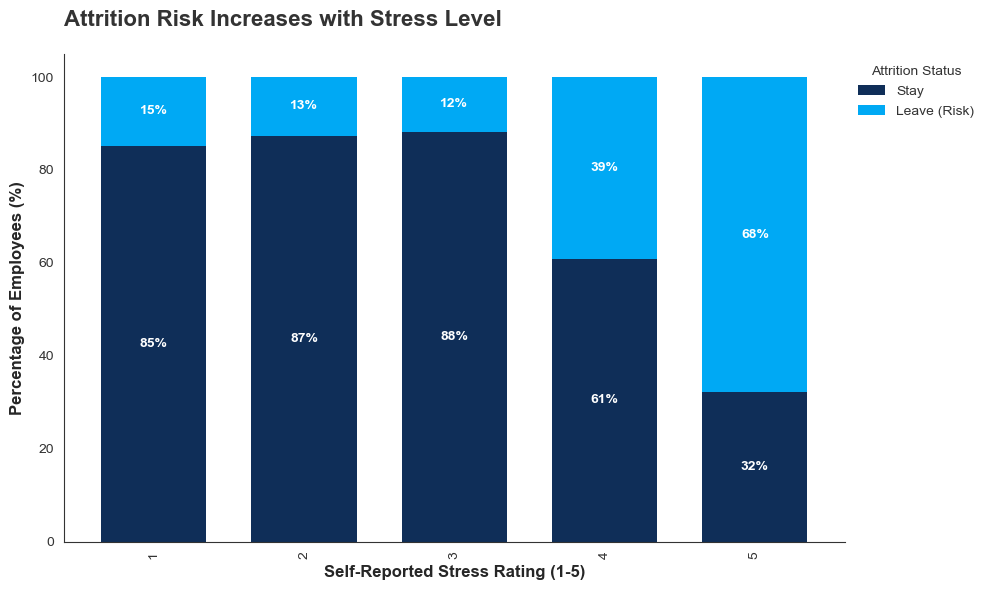

In [93]:
def set_theme():
    sns.set_style("white")
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    plt.rcParams['axes.edgecolor'] = '#333333'
    plt.rcParams['axes.linewidth'] = 0.8
    plt.rcParams['xtick.color'] = '#333333'
    plt.rcParams['ytick.color'] = '#333333'
    plt.rcParams['text.color'] = '#333333'
set_theme()

stress_data = df.groupby(['StressRating', 'Attrition']).size().unstack(fill_value=0)
stress_pct = stress_data.div(stress_data.sum(axis=1), axis=0) * 100 # Convert to %
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#0F2E58', '#00A9F4']
stress_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.7, edgecolor='none')
ax.set_title('Attrition Risk Increases with Stress Level', fontsize=16, fontweight='bold', loc='left', pad=20)
ax.set_xlabel('Self-Reported Stress Rating (1-5)', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Employees (%)', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='Attrition Status', labels=['Stay', 'Leave (Risk)'], 
          loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontweight='bold')
plt.tight_layout()
# plt.savefig('stress_level_vis.png', dpi=300)
plt.show()

##### Statistical Testing to Ensure This Phenomenon is Significant

In [95]:
stay_stress = df[df['Attrition'] == 'No']['StressRating']
leave_stress = df[df['Attrition'] == 'Yes']['StressRating']

stat, p_val = mannwhitneyu(stay_stress, leave_stress, alternative='less') 

print("\n" + "="*50)
print("STATISTICAL TEST RESULTS: STRESS RATING")
print("="*50)
print(f"Mann-Whitney U Statistic : {stat}")
print(f"P-Value                  : {p_val:.5f}")
if p_val < 0.05:
    print(">> CONCLUSION: SIGNIFICANT. Employees leave because of a higher stress level.")
else:
    print(">> CONCLUSION: NOT SIGNIFICANT. Not enough evidence.")


STATISTICAL TEST RESULTS: STRESS RATING
Mann-Whitney U Statistic : 114952.5
P-Value                  : 0.00000
>> CONCLUSION: SIGNIFICANT. Employees leave because of a higher stress level.


#### Q2: Are our incentive structures failing to retain high-performing talent, leading to 'regrettable churn'?

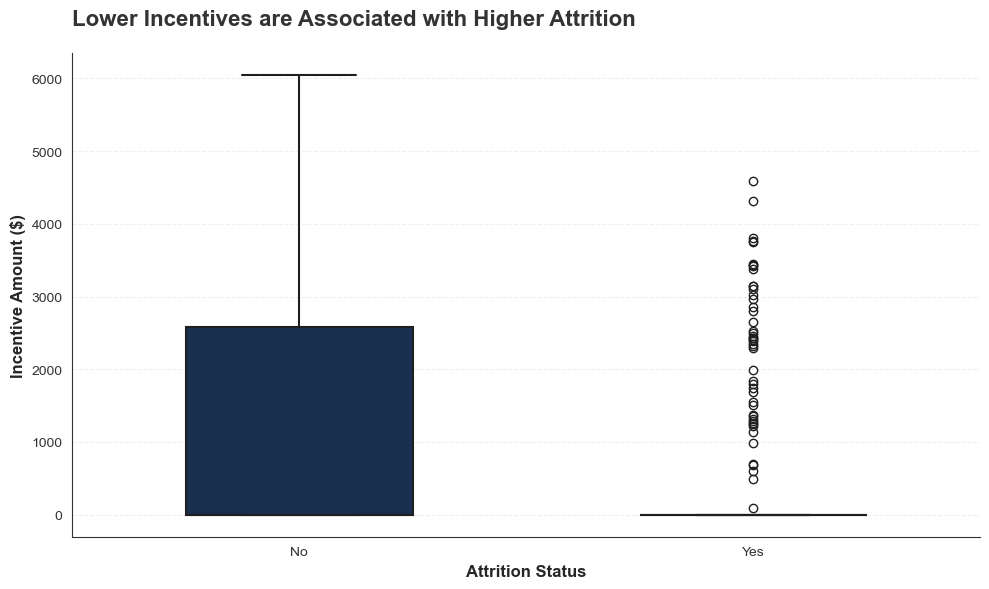

In [97]:
set_theme()
fig, ax = plt.subplots(figsize=(10, 6))

custom_pal = {'No': '#0F2E58', 'Yes': '#E74C3C'}
sns.boxplot(
    data=df, 
    x='Attrition', 
    y='Incentive', 
    palette=custom_pal,
    width=0.5,
    linewidth=1.5,
    order=['No', 'Yes'], # Stay first
    ax=ax
)
ax.set_title('Lower Incentives are Associated with Higher Attrition', fontsize=16, fontweight='bold', loc='left', pad=20)
ax.set_xlabel('Attrition Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Incentive Amount ($)', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3) # Horizontal grid only
plt.tight_layout()
# plt.savefig('incentives_vis.png', dpi=300)
plt.show()

In [98]:
stay_inc = df[df['Attrition'] == 'No']['Incentive']
leave_inc = df[df['Attrition'] == 'Yes']['Incentive']
stat, p_val = mannwhitneyu(stay_inc, leave_inc, alternative='greater')

print("\n" + "="*50)
print("STATISTICAL TEST RESULTS: INCENTIVE")
print("="*50)
print(f"Mann-Whitney U Statistic : {stat}")
print(f"P-Value                  : {p_val:.5f}")
if p_val < 0.05:
    print(">> CONCLUSION: SIGNIFICANT. Employees those are staying generally have higher incentives.")
else:
    print(">> CONCLUSION: NOT SIGNIFICANT. Incentive is not a main factor.")


STATISTICAL TEST RESULTS: INCENTIVE
Mann-Whitney U Statistic : 189747.5
P-Value                  : 0.00000
>> CONCLUSION: SIGNIFICANT. Employees those are staying generally have higher incentives.


## Business Quantification: Financial Impact Projection

To measure the finanicial impact of the potential solutions proposed in the business proposal, the following calculation has been done.

FINANCIAL PROJECTION (INC. CAPEX)
1. INVESTMENT
   - CAPEX (Model Build)  : $100,000
   - ANNUAL LICENSE       : $25,000
   - OPEX (Intervention)  : $55,000
   - TOTAL INVESTMENT     : $180,000

2. OUTCOME
   - Loss (Status Quo)    : $480,000
   - Loss (With Model)    : $120,000 (Remaining Churn)
   - TOTAL COST Year 1    : $300,000 (Inv + Remaining Loss)
----------------------------------------------------------------------
NET SAVINGS (Year 1)      : $180,000
ROI (Year 1)              : 100.0%


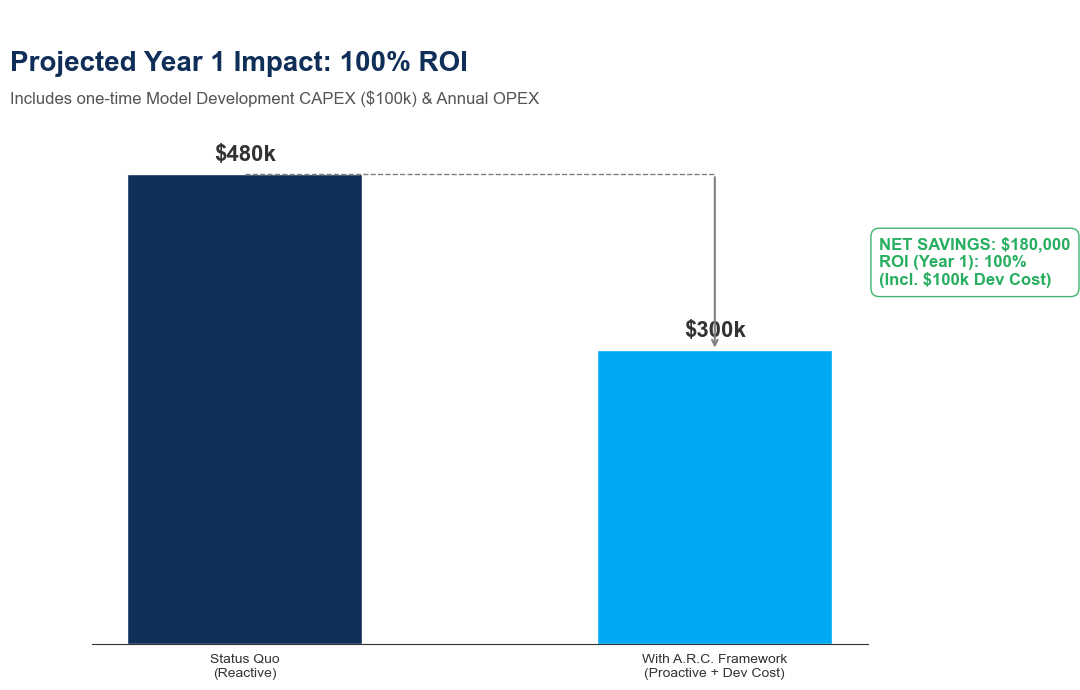

In [168]:
# Assumptions
TP = 36
FN = 12
FP = 74

COST_PER_REPLACEMENT = 10000
COST_PER_INTERVENTION = 500  # OPEX per head
CAPEX_MODEL_DEV = 100000     # One-time build cost
ANNUAL_LICENSE = 25000

# Scenario A: Status Quo (Do Nothing)
total_churn_count = TP + FN
loss_status_quo = total_churn_count * COST_PER_REPLACEMENT

# Scenario B: With Model
total_targeted_employees = TP + FP
cost_opex_program = total_targeted_employees * COST_PER_INTERVENTION
loss_missed_churn = FN * COST_PER_REPLACEMENT

# Total Investment (Year 1)
total_investment = CAPEX_MODEL_DEV + ANNUAL_LICENSE + cost_opex_program

# Total Financial Impact with Model
total_cost_scenario_b = total_investment + loss_missed_churn

# ROI Calculation
gross_savings = loss_status_quo - loss_missed_churn
net_savings = gross_savings - total_investment
roi = (net_savings / total_investment) * 100 if total_investment > 0 else 0

fig, ax = plt.subplots(figsize=(11, 7), facecolor='white')
# Data for plotting
costs = [loss_status_quo, total_cost_scenario_b]
labels = ['Status Quo\n(Reactive)', 'With A.R.C. Framework\n(Proactive + Dev Cost)']
colors = ['#0F2E58', '#00A9F4']  # Navy, Cyan

bars = ax.bar(labels, costs, color=colors, width=0.5)

# Styling
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#333333')

# Labeling Bars
for bar in bars:
    height = bar.get_height()
    label = f"${height/1000:,.0f}k"
    ax.text(bar.get_x() + bar.get_width()/2., height + (max(costs)*0.02),
            label, ha='center', va='bottom', fontsize=16, fontweight='bold', color='#333333')

# Waterfall / Savings Arrow
if net_savings > 0:
    x_start = bars[0].get_x() + bars[0].get_width()/2
    x_end = bars[1].get_x() + bars[1].get_width()/2
    y_start = costs[0]
    y_end = costs[1]
    
    # Arrow
    ax.annotate('', xy=(x_end, y_end), xytext=(x_end, y_start),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.plot([x_start, x_end], [y_start, y_start], color='gray', linestyle='--', linewidth=1)
    
    # ROI Text Box
    mid_y = (y_start + y_end) / 2
    text_str = (f"NET SAVINGS: ${net_savings:,.0f}\n"
                f"ROI (Year 1): {roi:.0f}%\n"
                f"(Incl. ${CAPEX_MODEL_DEV/1000:.0f}k Dev Cost)")
    
    bbox_props = dict(boxstyle="round,pad=0.5", fc="white", ec="#27AE60", alpha=0.9)
    ax.text(x_end + 0.35, mid_y, text_str, ha='left', va='center', 
            fontsize=12, color='#27AE60', fontweight='bold', bbox=bbox_props)

# Title
plt.text(x=-0.5, y=max(costs)*1.22, 
         s=f"Projected Year 1 Impact: {roi:.0f}% ROI", 
         fontsize=20, fontweight='bold', color='#0F2E58')

# Subtitle
plt.text(x=-0.5, y=max(costs)*1.15, 
         s="Includes one-time Model Development CAPEX ($100k) & Annual OPEX", 
         fontsize=12, color='#555555')

plt.ylim(0, max(costs)*1.35)
plt.tight_layout()
# plt.savefig('financial_projection.png', dpi=300)

print(f"FINANCIAL PROJECTION (INC. CAPEX)")
print(70 * "=")
print(f"1. INVESTMENT")
print(f"   - CAPEX (Model Build)  : ${CAPEX_MODEL_DEV:,.0f}")
print(f"   - ANNUAL LICENSE       : ${ANNUAL_LICENSE:,.0f}")
print(f"   - OPEX (Intervention)  : ${cost_opex_program:,.0f}")
print(f"   - TOTAL INVESTMENT     : ${total_investment:,.0f}")
print(f"\n2. OUTCOME")
print(f"   - Loss (Status Quo)    : ${loss_status_quo:,.0f}")
print(f"   - Loss (With Model)    : ${loss_missed_churn:,.0f} (Remaining Churn)")
print(f"   - TOTAL COST Year 1    : ${total_cost_scenario_b:,.0f} (Inv + Remaining Loss)")
print(70 * "-")
print(f"NET SAVINGS (Year 1)      : ${net_savings:,.0f}")
print(f"ROI (Year 1)              : {roi:.1f}%")
print(70 * "=")